<a href="https://www.kaggle.com/code/omborse771924/strava-segments-in-vietnam-eda?scriptVersionId=334379609" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/evgenyarbatov/personal-vietnam-strava-segments/strava_segments.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/evgenyarbatov/personal-vietnam-strava-segments/strava_segments.csv')

In [3]:
df.head()

,segment_id,name,country,distance,city,athlete_count,polyline
0,26131055,Bay Mau Lake 2.4km Loop,Vietnam,2397.0,Hà Nội,35049,ggf_C{{_eSc@OUAe@?SFe@GS@g@Ji@Cg@BmAMQH_@XSDe@...
1,31531255,800m dash,Vietnam,804.0,Hà Nội,53403,mmg_Cai_eSCz@Db@FLDDVFPANE^Wb@E\Fh@N|AD~AGhDDd...
2,14587584,Full Loop,Vietnam,2989.5,Hà Nội,6562,mug_Ccf`eSE]HQ@KGMIAq@NKJc@PKBGFGf@JTDT_@p@DPh...
3,33834390,Vỉa Cảm Tử,Vietnam,306.0,Hanoi,108108,_pj_CcpaeS]PUDs@f@]Fg@Rs@b@ILGR?TLd@Bh@KxABb@Ef@
4,33834431,Vỉa Thủy Tạ,Vietnam,302.0,Hanoi,99714,awj_CchaeSK`BBb@Er@N\RL`@d@VJd@Dv@Cd@Op@Gr@W


In [4]:
df.tail()

,segment_id,name,country,distance,city,athlete_count,polyline
255,26453966,Cau Dao Kim Cuong towards Diamond Island,Vietnam,477.3,Thành phố Hồ Chí Minh,24275,mjx`AedojSFII@B?j@sAX[p@iA|AaD^aAb@yArBaF
256,22653771,Kim Cuong riverside,Vietnam,492.0,Hồ Chí Minh,19815,}pw`AmlpjSYZc@p@sCzC}@tAU`@]x@cAvCw@xAo@pA
257,26453992,Cau Dao Kim Cuong towards Mai Chi Tho,Vietnam,457.5,Thành phố Hồ Chí Minh,24216,}}w`Ag{ojSWr@a@h@cAnBYfAw@xBsBnESj@q@pA
258,22653866,Double Cá Trê bridge,Vietnam,727.0,Hồ Chí Minh,26726,iux`AemnjSZv@\nAb@fAv@lAVd@~@nCp@|A?DZz@zAjD@D...
259,36744053,Sala-Thu Thiem 1K,Vietnam,1002.8,Hồ Chí Minh City,45415,uou`Ak_ljSNpBLdCBbEAfBIfCM`CIf@Cd@Gd@Cd@UdBq@v...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   segment_id     260 non-null    int64  
 1   name           260 non-null    object 
 2   country        260 non-null    object 
 3   distance       260 non-null    float64
 4   city           260 non-null    object 
 5   athlete_count  260 non-null    int64  
 6   polyline       260 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 14.3+ KB


In [6]:
df.describe()

,segment_id,distance,athlete_count
count,2.600000e+02,260.000000,260.000000
mean,2.503766e+07,1283.742527,18479.984615
std,1.087773e+07,1266.214706,21728.333895
min,1.337572e+06,151.700000,33.000000
25%,1.637989e+07,492.550000,3844.000000
50%,2.803281e+07,847.150000,11285.500000
75%,3.391410e+07,1566.050000,25646.250000
max,4.109998e+07,7388.400000,108108.000000


In [7]:
df.isnull

<bound method DataFrame.isnull of      segment_id                                      name  country  distance  \
0      26131055                   Bay Mau Lake 2.4km Loop  Vietnam    2397.0   
1      31531255                                800m dash   Vietnam     804.0   
2      14587584                                 Full Loop  Vietnam    2989.5   
3      33834390                                Vỉa Cảm Tử  Vietnam     306.0   
4      33834431                               Vỉa Thủy Tạ  Vietnam     302.0   
..          ...                                       ...      ...       ...   
255    26453966  Cau Dao Kim Cuong towards Diamond Island  Vietnam     477.3   
256    22653771                       Kim Cuong riverside  Vietnam     492.0   
257    26453992     Cau Dao Kim Cuong towards Mai Chi Tho  Vietnam     457.5   
258    22653866                      Double Cá Trê bridge  Vietnam     727.0   
259    36744053                         Sala-Thu Thiem 1K  Vietnam    1002.8   

     

In [8]:
df.isnull().sum()

segment_id       0
name             0
country          0
distance         0
city             0
athlete_count    0
polyline         0
dtype: int64

In [9]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
255    False
256    False
257    False
258    False
259    False
Length: 260, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['segment_id', 'name', 'country', 'distance', 'city', 'athlete_count',
       'polyline'],
      dtype='object')

## EDA

DATASET SHAPE
(260, 7)
FIRST 5 ROWS
   segment_id                     name  country  distance    city  \
0    26131055  Bay Mau Lake 2.4km Loop  Vietnam    2397.0  Hà Nội   
1    31531255               800m dash   Vietnam     804.0  Hà Nội   
2    14587584                Full Loop  Vietnam    2989.5  Hà Nội   
3    33834390               Vỉa Cảm Tử  Vietnam     306.0   Hanoi   
4    33834431              Vỉa Thủy Tạ  Vietnam     302.0   Hanoi   

   athlete_count                                           polyline  
0          35049  ggf_C{{_eSc@OUAe@?SFe@GS@g@Ji@Cg@BmAMQH_@XSDe@...  
1          53403  mmg_Cai_eSCz@Db@FLDDVFPANE^Wb@E\Fh@N|AD~AGhDDd...  
2           6562  mug_Ccf`eSE]HQ@KGMIAq@NKJc@PKBGFGf@JTDT_@p@DPh...  
3         108108   _pj_CcpaeS]PUDs@f@]Fg@Rs@b@ILGR?TLd@Bh@KxABb@Ef@  
4          99714       awj_CchaeSK`BBb@Er@N\RL`@d@VJd@Dv@Cd@Op@Gr@W  
DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 7 columns):
 #   Col

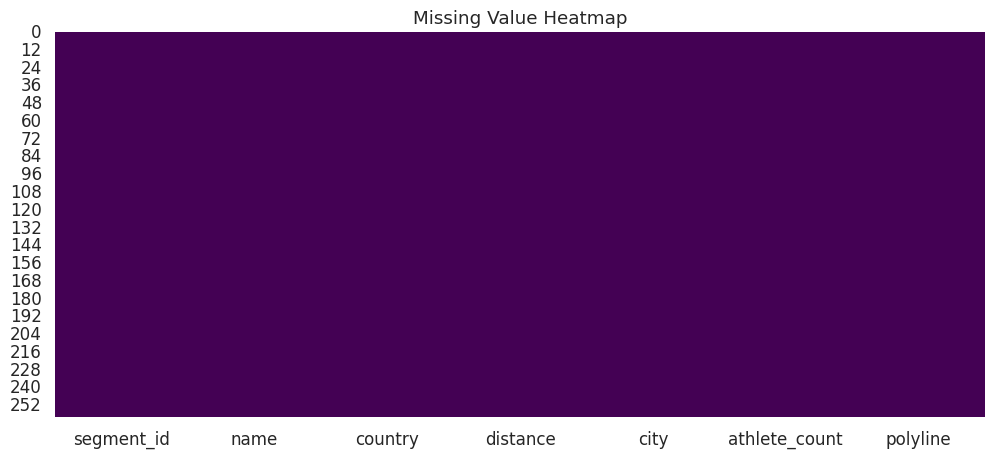


Numerical Columns
Index(['segment_id', 'distance', 'athlete_count'], dtype='object')

Categorical Columns
Index(['name', 'country', 'city', 'polyline'], dtype='object')


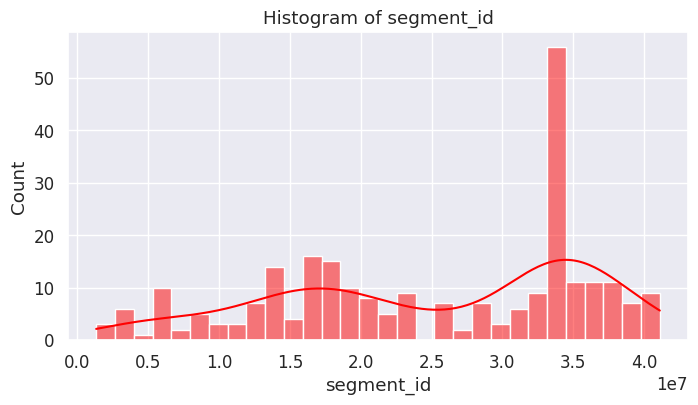

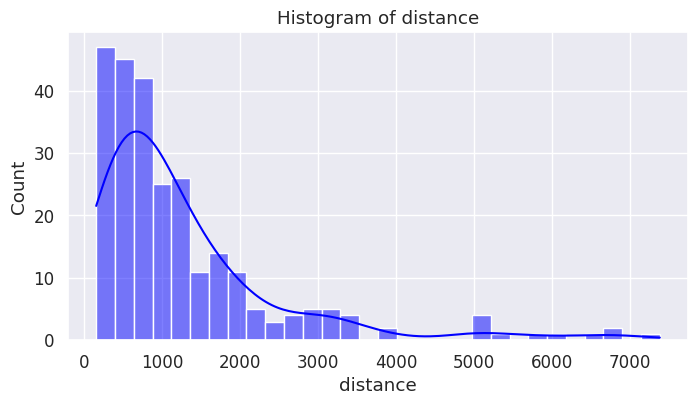

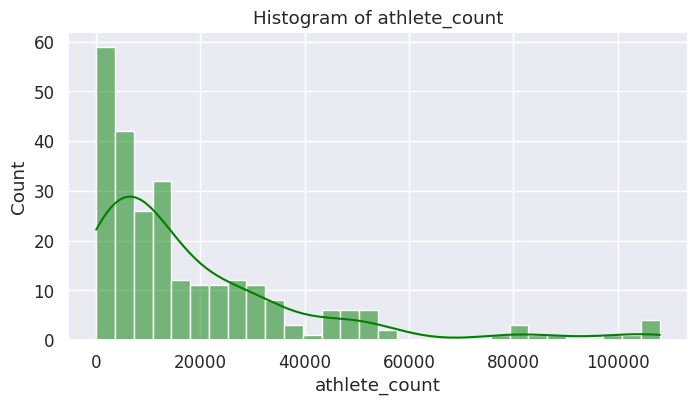

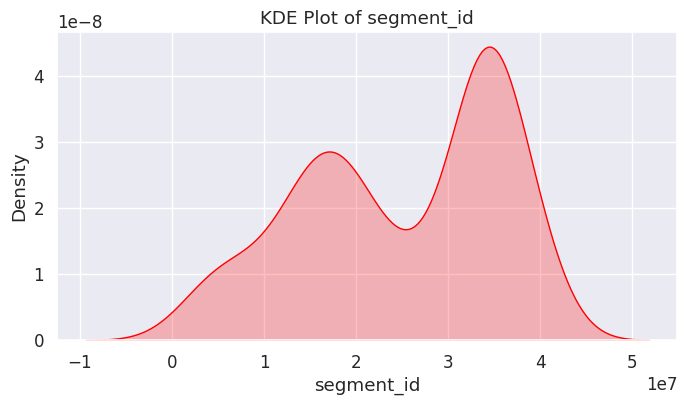

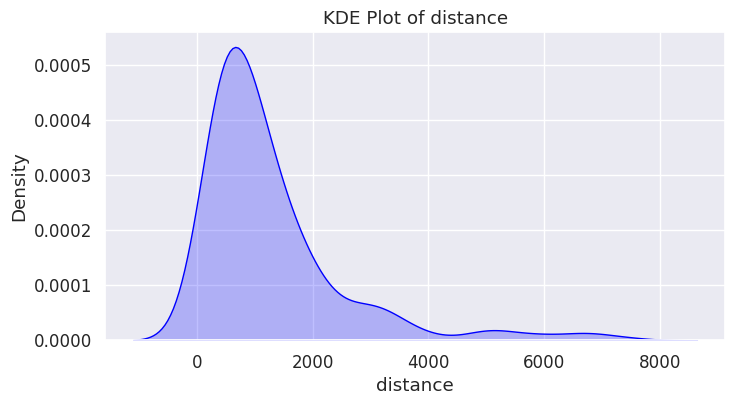

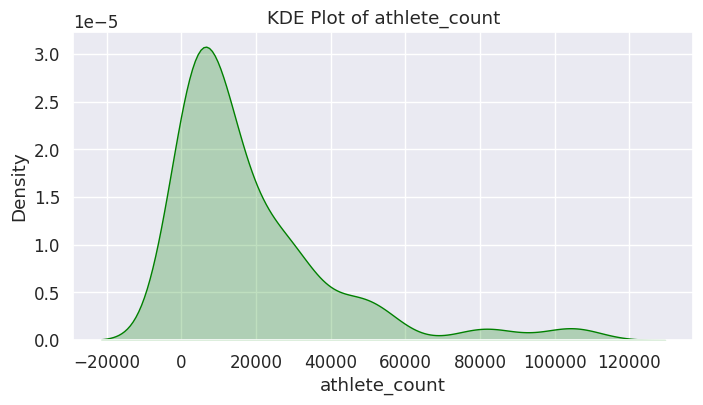

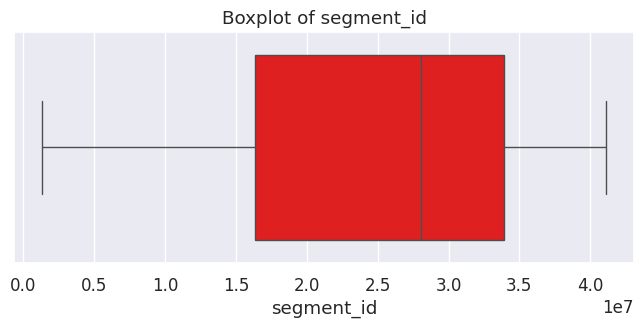

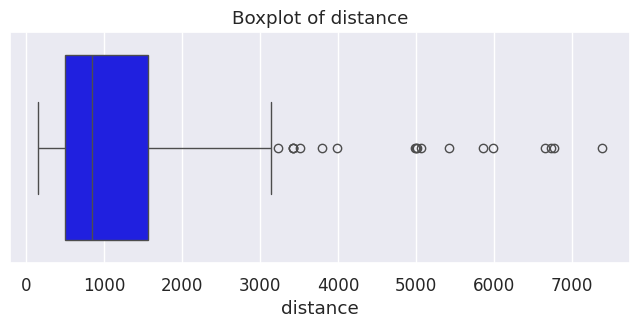

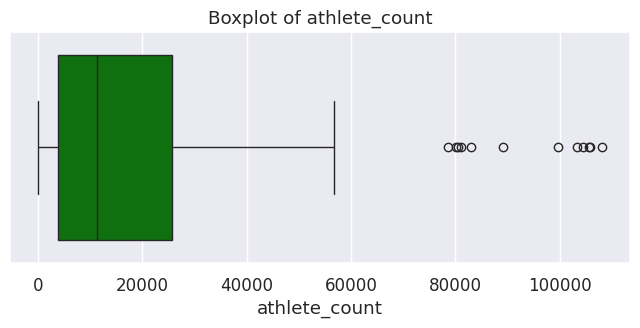

PART 1 COMPLETED


In [12]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

data = df.copy()

# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("="*70)
print("DATASET SHAPE")
print(data.shape)

print("="*70)
print("FIRST 5 ROWS")
print(data.head())

print("="*70)
print("DATA INFORMATION")
print(data.info())

print("="*70)
print("MISSING VALUES")
print(data.isnull().sum())

print("="*70)
print("STATISTICAL SUMMARY")
print(data.describe(include="all"))

# ==========================================================
# MISSING VALUE HEATMAP
# ==========================================================

plt.figure(figsize=(12,5))

sns.heatmap(
    data.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Heatmap")

plt.show()

# ==========================================================
# NUMERICAL & CATEGORICAL COLUMNS
# ==========================================================

num_cols = data.select_dtypes(include=np.number).columns

cat_cols = data.select_dtypes(include="object").columns

print("\nNumerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

# ==========================================================
# HISTOGRAMS
# ==========================================================

colors=[
'red','blue','green','orange',
'purple','brown','cyan','magenta',
'gold','pink','olive','teal'
]

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.histplot(
        data[col],
        bins=30,
        kde=True,
        color=colors[i%len(colors)]
    )

    plt.title(f"Histogram of {col}")

    plt.show()

# ==========================================================
# KDE PLOTS
# ==========================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data[col],
        fill=True,
        color=colors[i%len(colors)]
    )

    plt.title(f"KDE Plot of {col}")

    plt.show()

# ==========================================================
# BOXPLOTS
# ==========================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=data[col],
        color=colors[i%len(colors)]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

print("="*70)
print("PART 1 COMPLETED")
print("="*70)

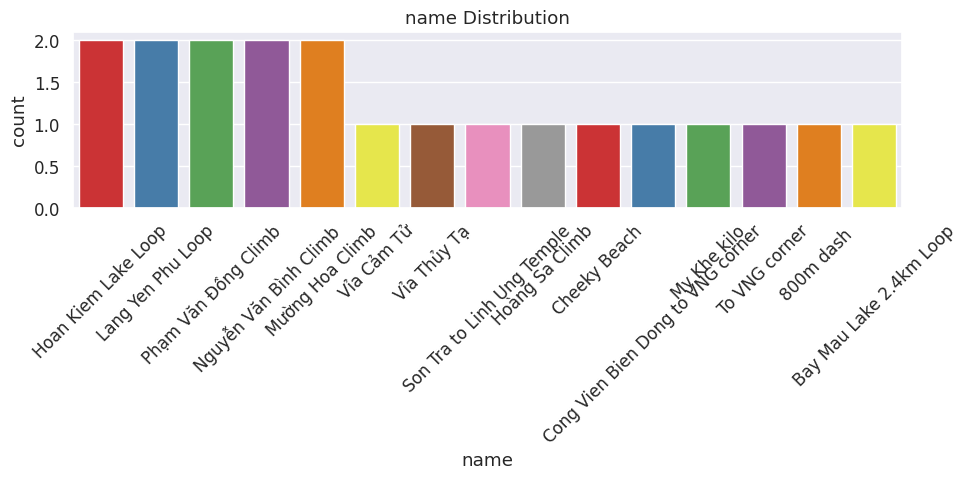

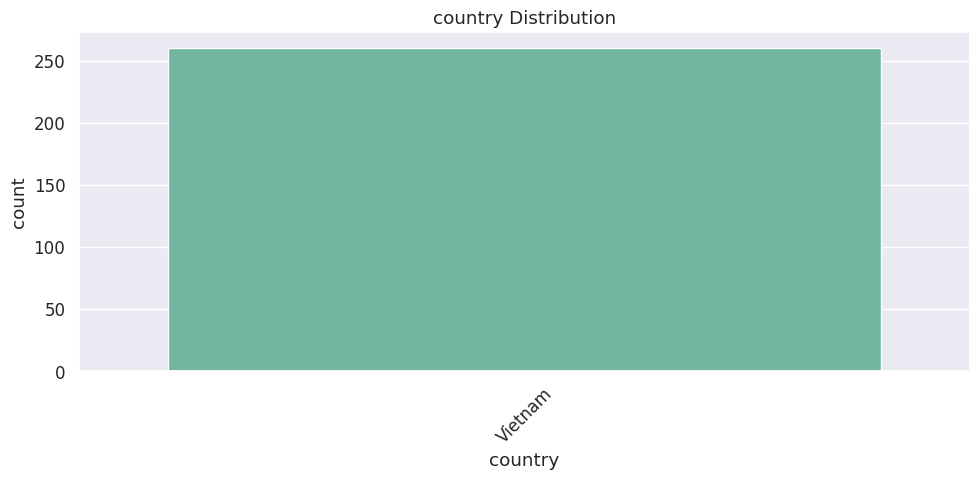

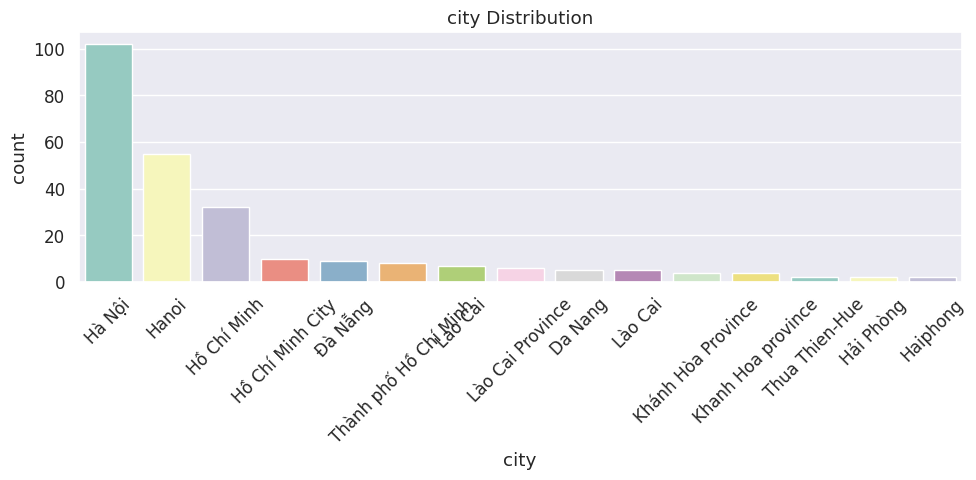

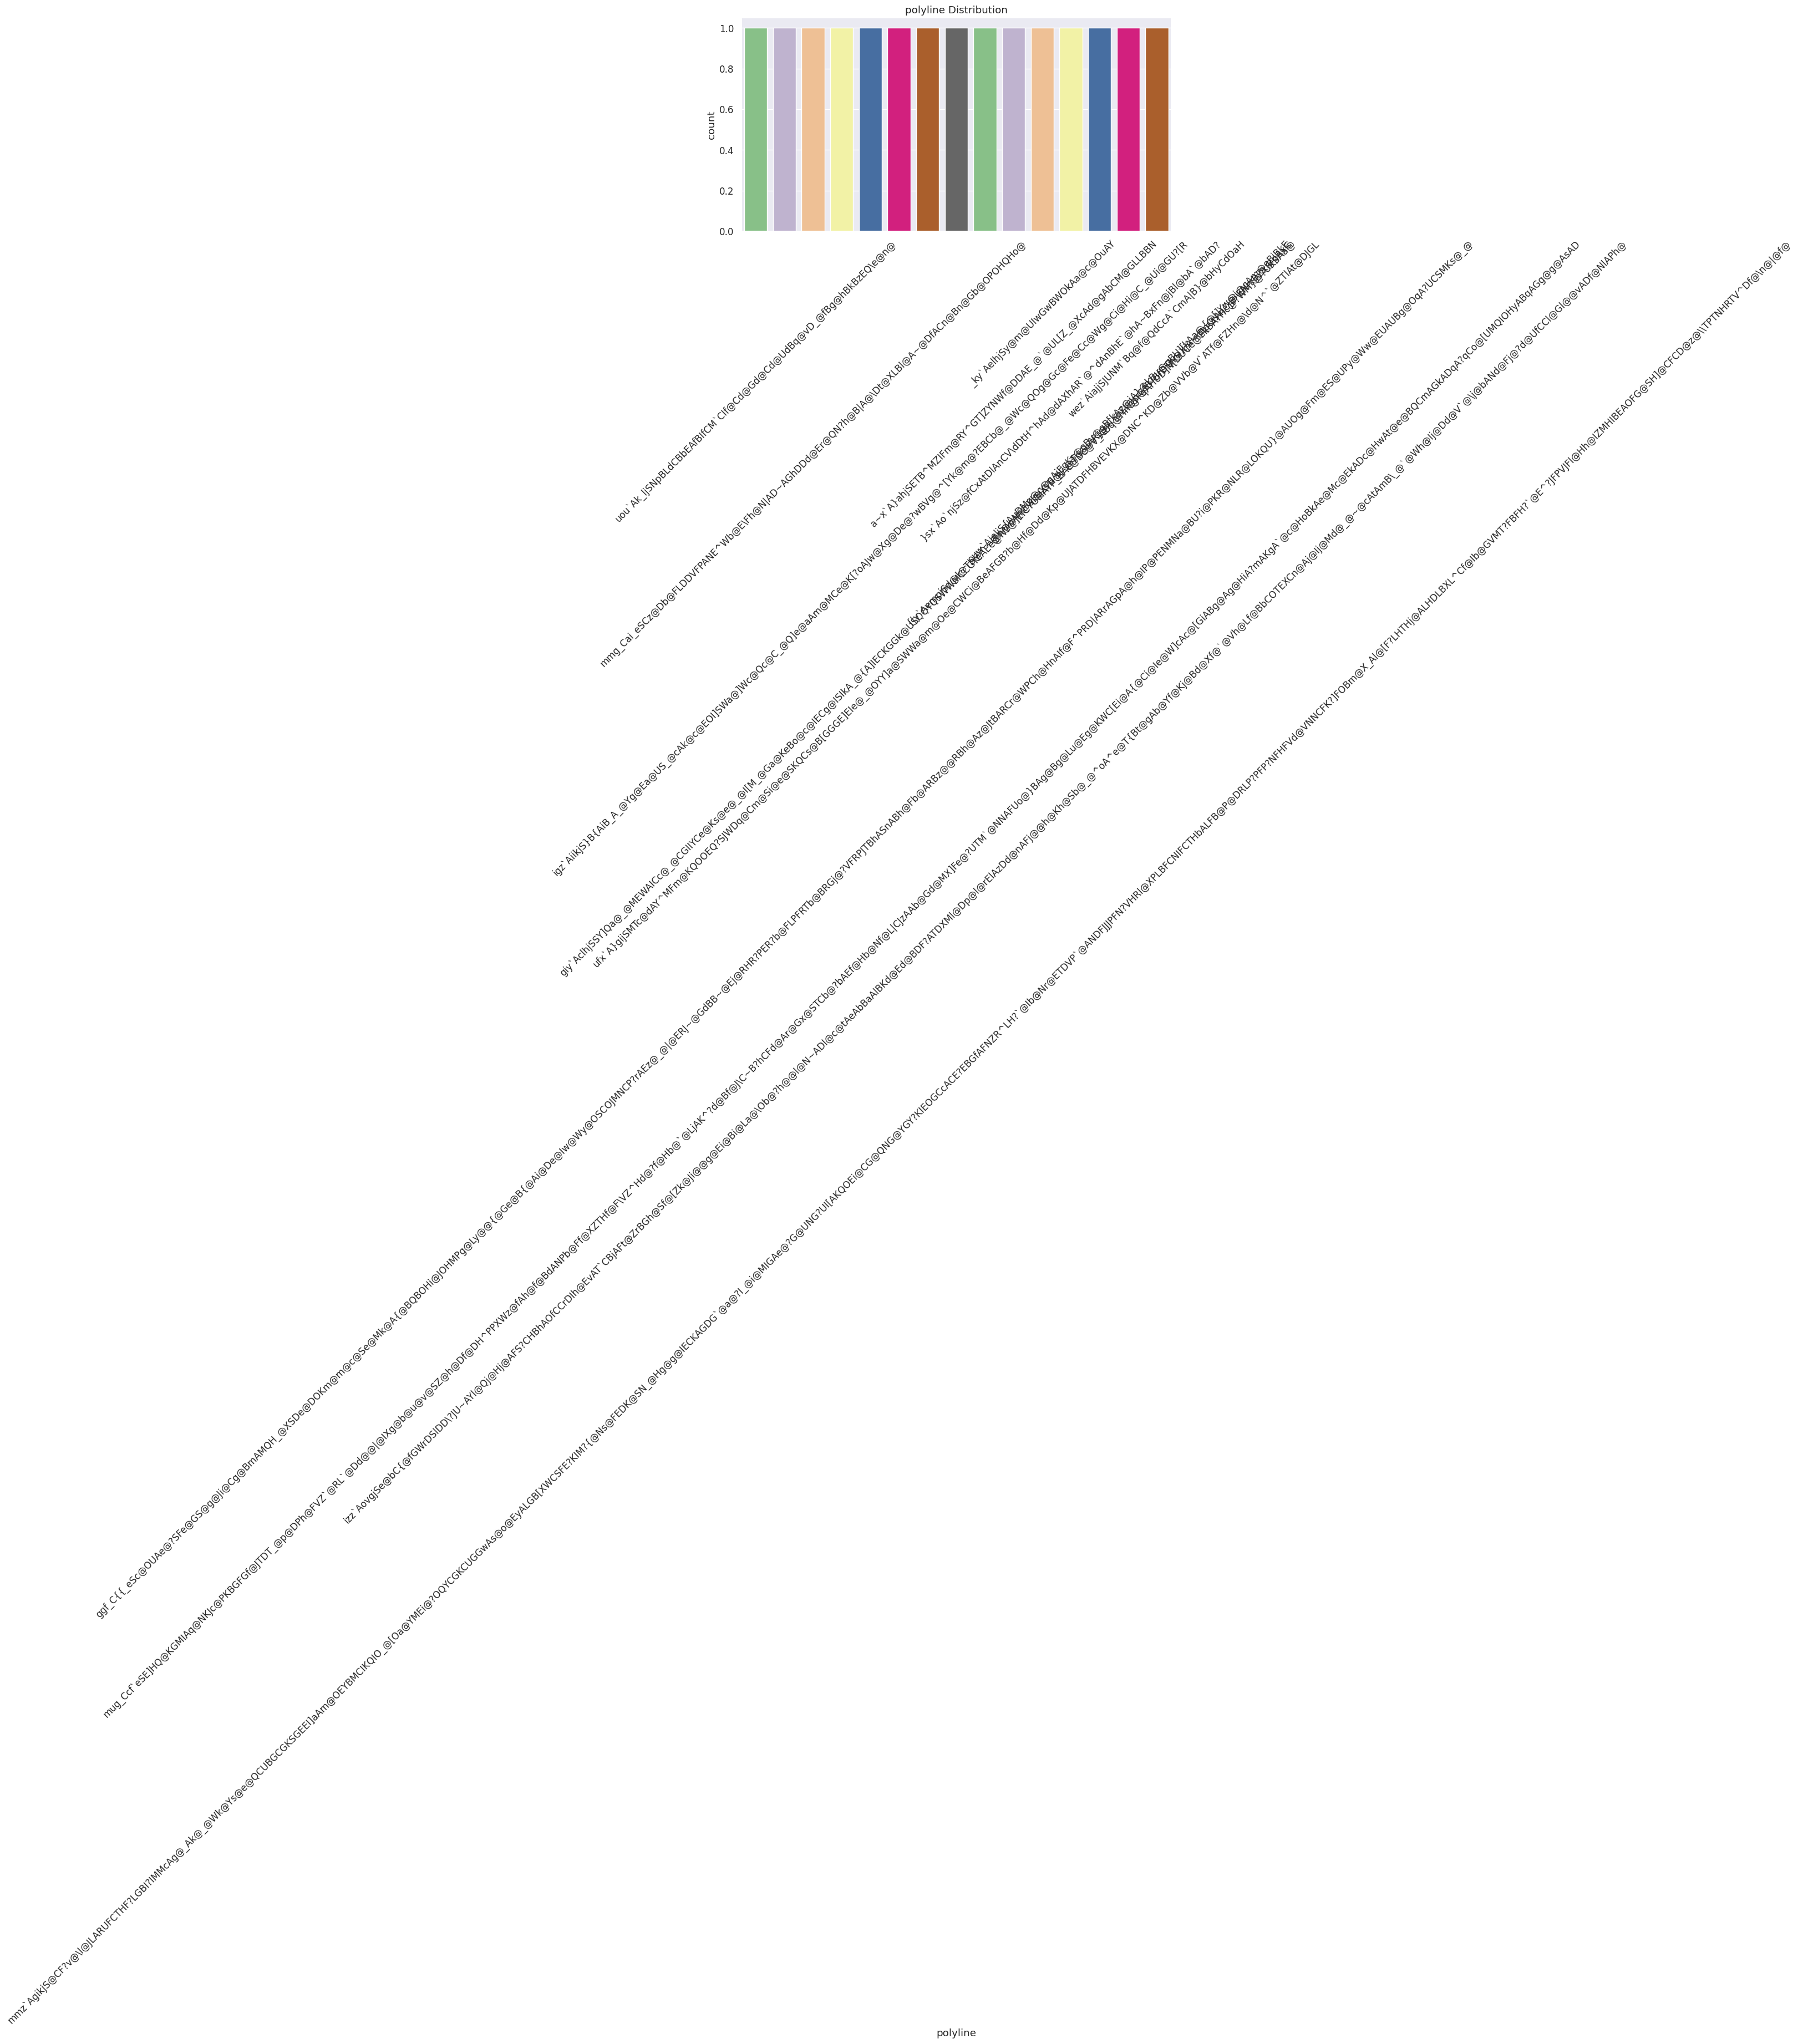

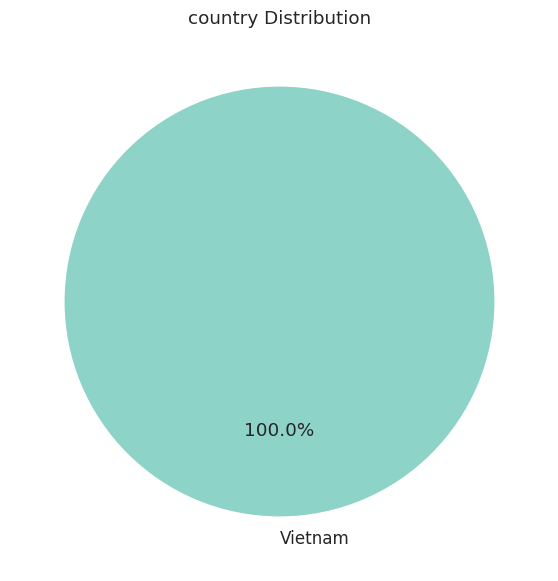

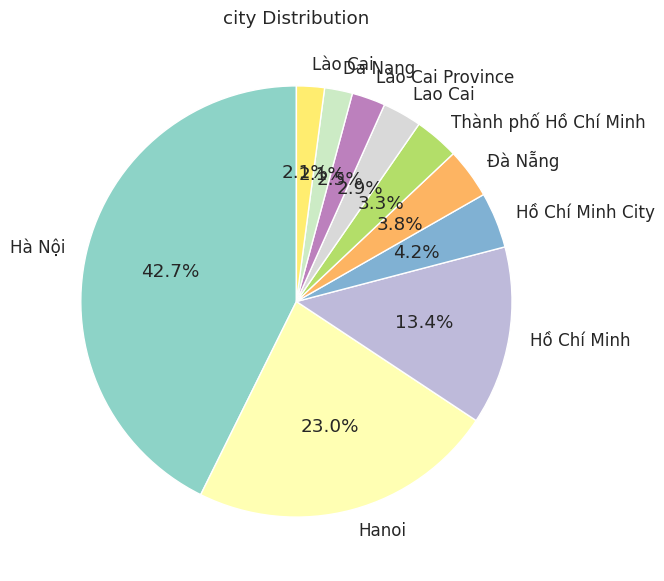

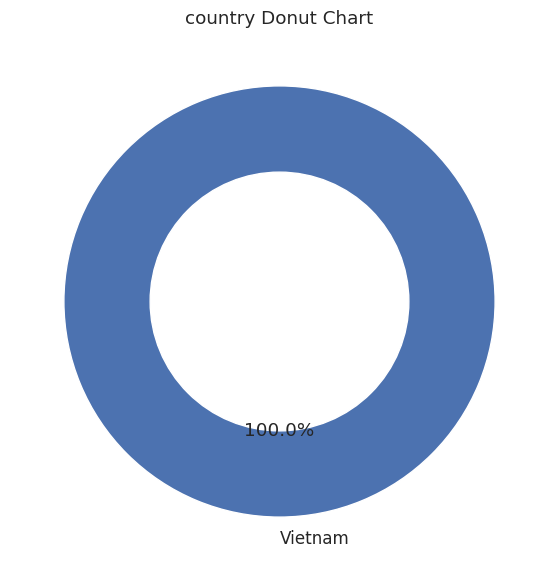

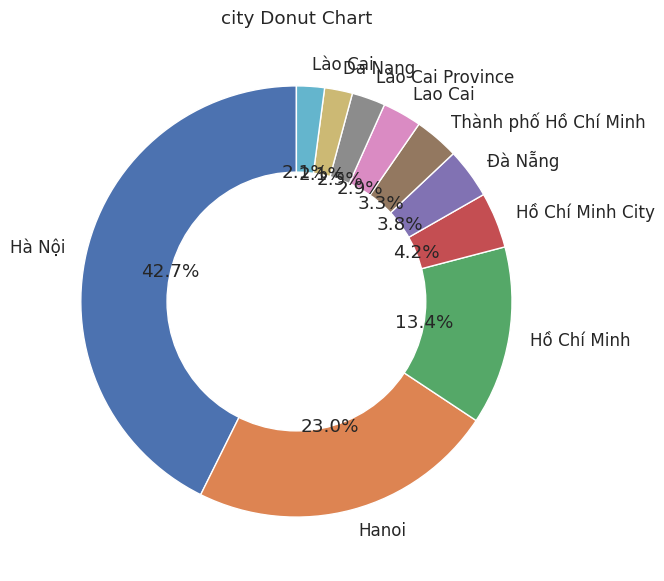

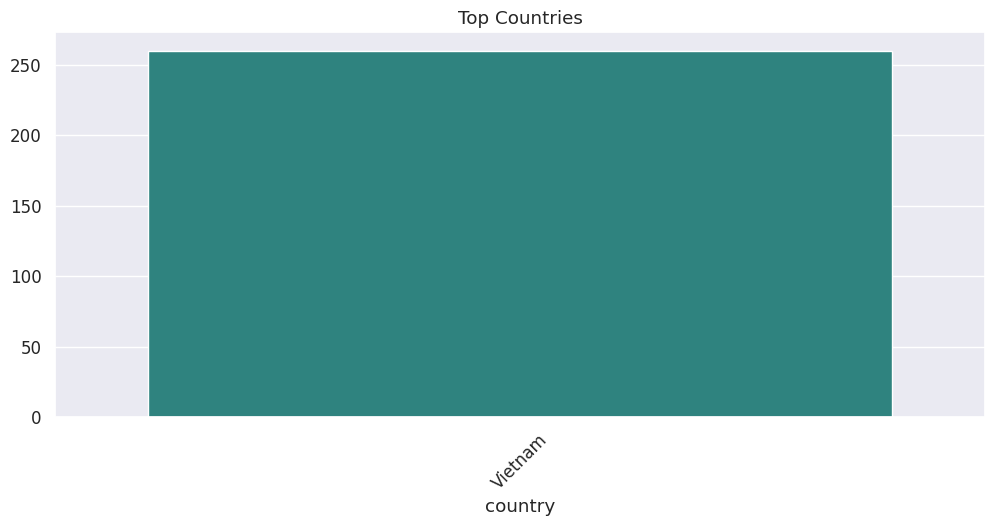

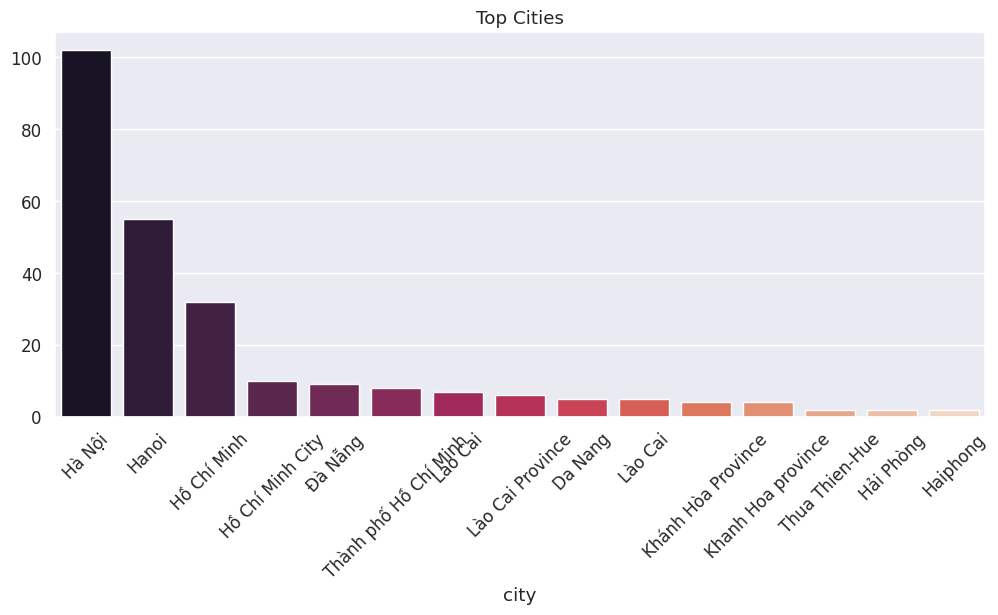

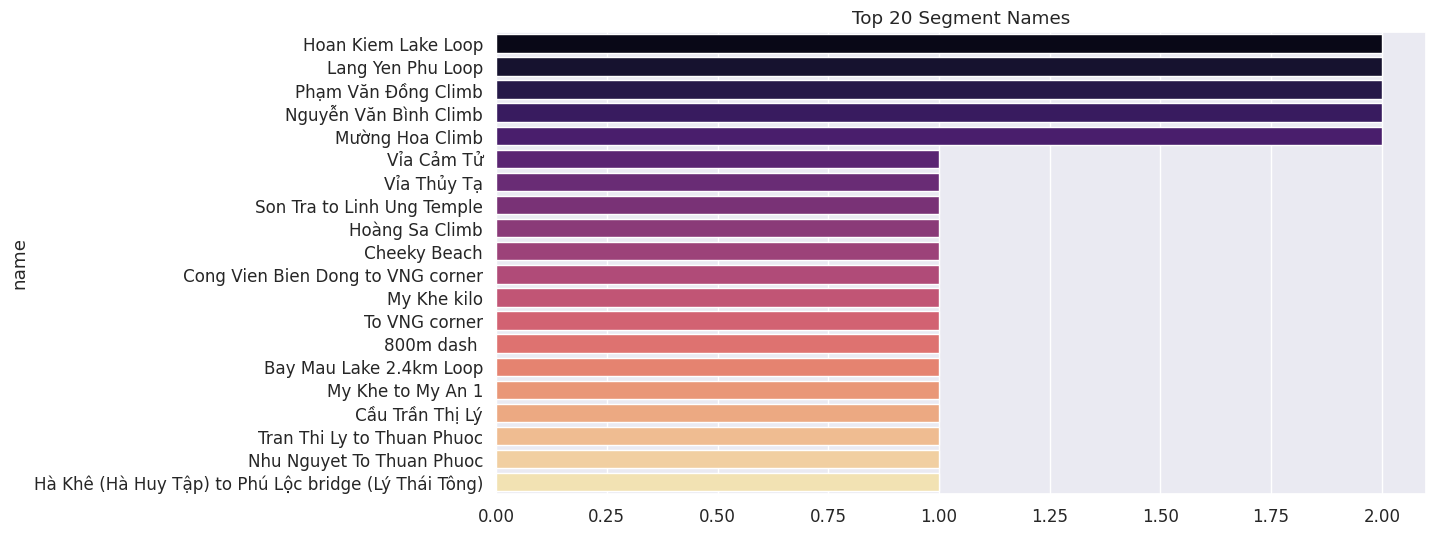

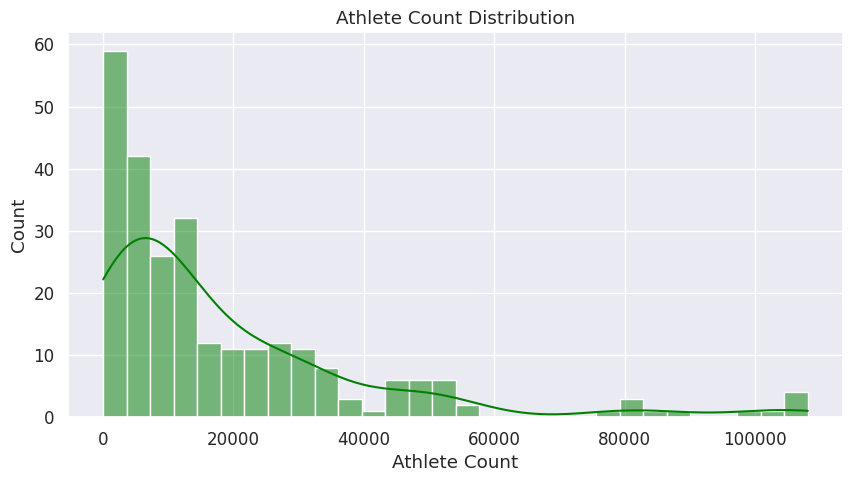

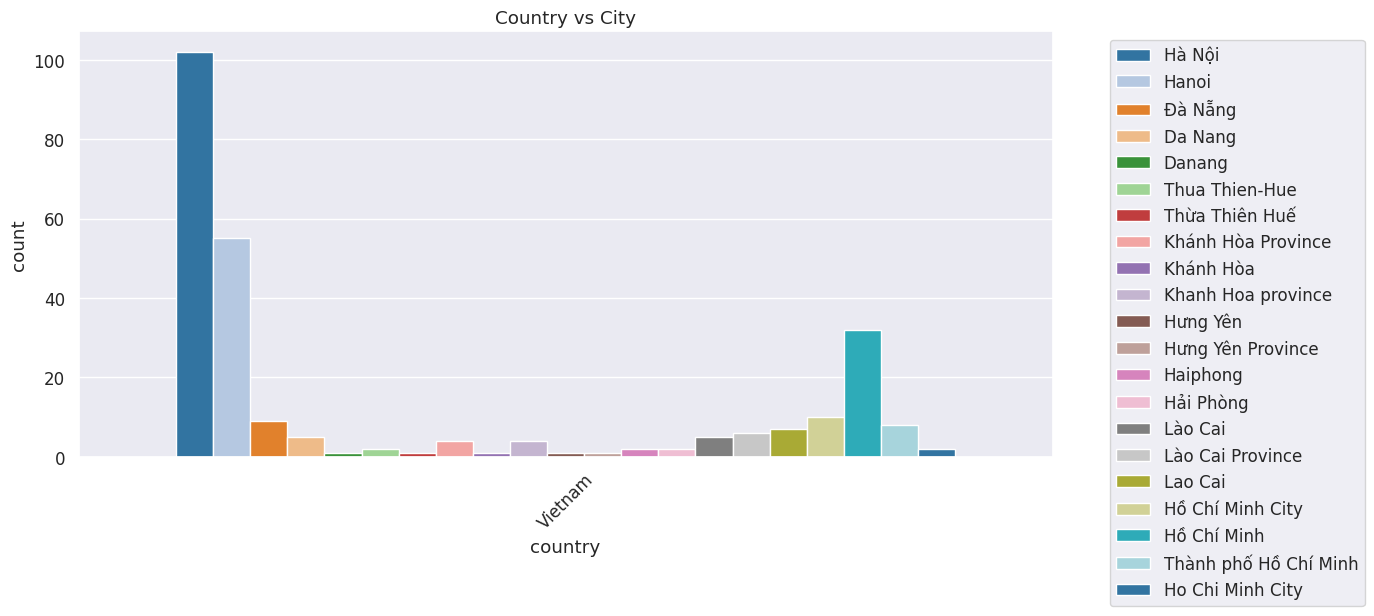

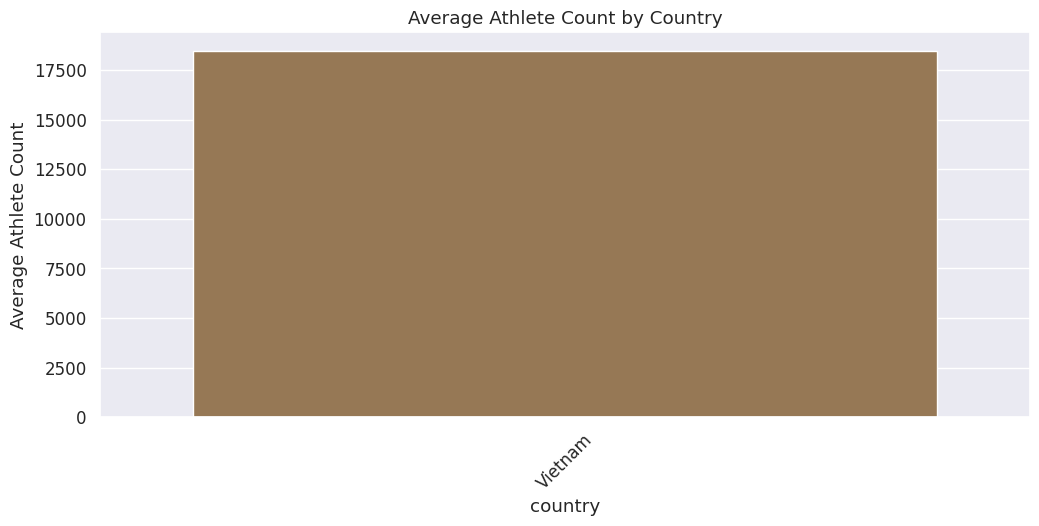

PART 2 COMPLETED


In [13]:
# ==========================================================
# PART 2 : CATEGORICAL VISUALIZATIONS
# ==========================================================

palettes = [
    "Set1","Set2","Set3","Accent","Dark2",
    "Paired","Pastel1","Pastel2","rocket",
    "mako","crest","flare","viridis",
    "Spectral","coolwarm"
]

# ==========================================================
# COUNTPLOTS
# ==========================================================

for i, col in enumerate(cat_cols):

    plt.figure(figsize=(10,5))

    order = data[col].value_counts().index[:15]

    sns.countplot(
        data=data,
        x=col,
        order=order,
        palette=palettes[i % len(palettes)]
    )

    plt.title(f"{col} Distribution")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

# ==========================================================
# PIE CHARTS
# ==========================================================

pie_cols = ["country", "city"]

for col in pie_cols:

    if col in data.columns:

        plt.figure(figsize=(7,7))

        data[col].value_counts().head(10).plot(
            kind="pie",
            autopct="%1.1f%%",
            startangle=90,
            cmap="Set3"
        )

        plt.ylabel("")

        plt.title(f"{col} Distribution")

        plt.show()

# ==========================================================
# DONUT CHARTS
# ==========================================================

for col in pie_cols:

    if col in data.columns:

        counts = data[col].value_counts().head(10)

        fig, ax = plt.subplots(figsize=(7,7))

        ax.pie(
            counts,
            labels=counts.index,
            autopct="%1.1f%%",
            startangle=90
        )

        centre_circle = plt.Circle((0,0),0.60,fc="white")

        fig.gca().add_artist(centre_circle)

        plt.title(f"{col} Donut Chart")

        plt.show()

# ==========================================================
# TOP COUNTRIES
# ==========================================================

plt.figure(figsize=(12,5))

country = data["country"].value_counts().head(15)

sns.barplot(
    x=country.index,
    y=country.values,
    palette="viridis"
)

plt.title("Top Countries")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# TOP CITIES
# ==========================================================

plt.figure(figsize=(12,5))

city = data["city"].value_counts().head(15)

sns.barplot(
    x=city.index,
    y=city.values,
    palette="rocket"
)

plt.title("Top Cities")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# TOP SEGMENT NAMES
# ==========================================================

plt.figure(figsize=(12,6))

segment = data["name"].value_counts().head(20)

sns.barplot(
    x=segment.values,
    y=segment.index,
    palette="magma"
)

plt.title("Top 20 Segment Names")

plt.show()

# ==========================================================
# ATHLETE COUNT DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    data["athlete_count"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Athlete Count Distribution")

plt.xlabel("Athlete Count")

plt.show()

# ==========================================================
# COUNTRY VS CITY
# ==========================================================

top_countries = data["country"].value_counts().head(8).index

filtered = data[data["country"].isin(top_countries)]

plt.figure(figsize=(14,6))

sns.countplot(
    data=filtered,
    x="country",
    hue="city",
    palette="tab20"
)

plt.title("Country vs City")

plt.xticks(rotation=45)

plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()

plt.show()

# ==========================================================
# COUNTRY VS ATHLETE COUNT
# ==========================================================

country_avg = (
    data.groupby("country")["athlete_count"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=country_avg.index,
    y=country_avg.values,
    palette="cubehelix"
)

plt.title("Average Athlete Count by Country")

plt.xticks(rotation=45)

plt.ylabel("Average Athlete Count")

plt.show()

print("="*70)
print("PART 2 COMPLETED")
print("="*70)

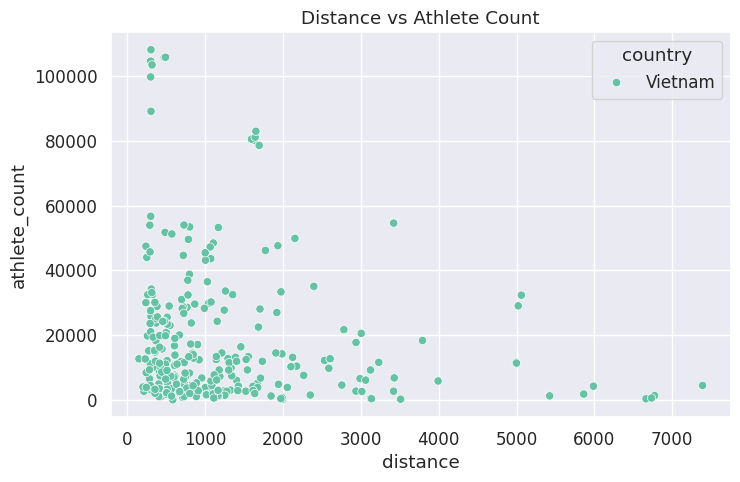

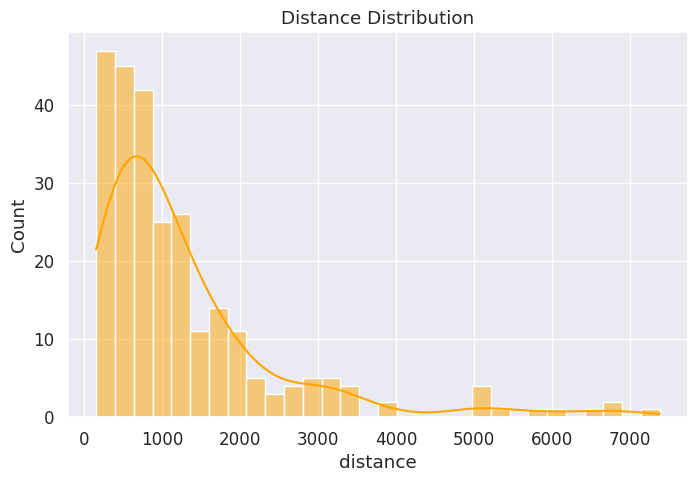

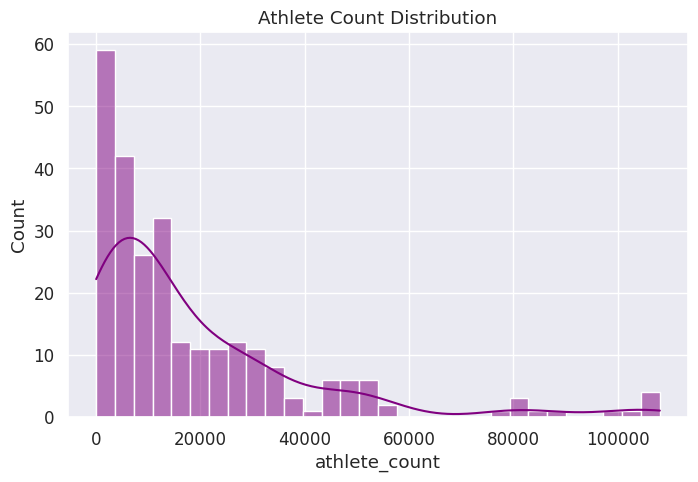

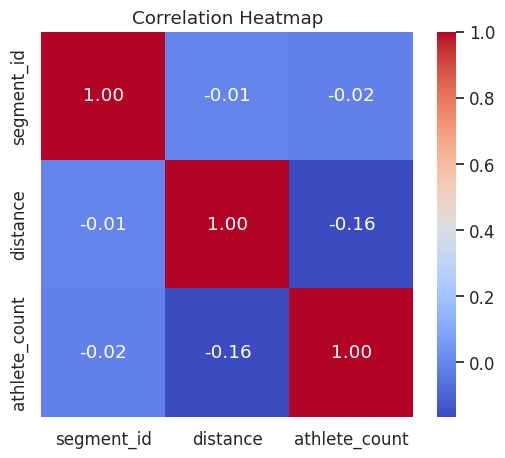

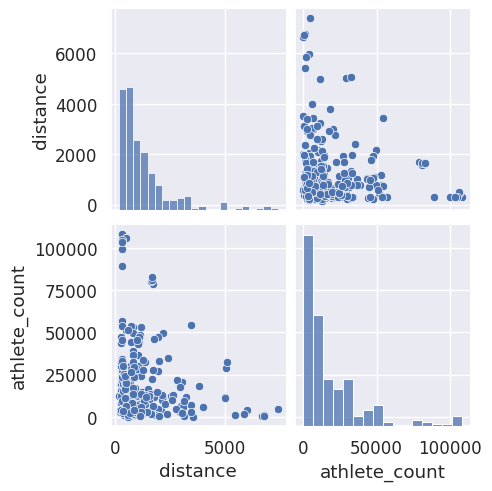

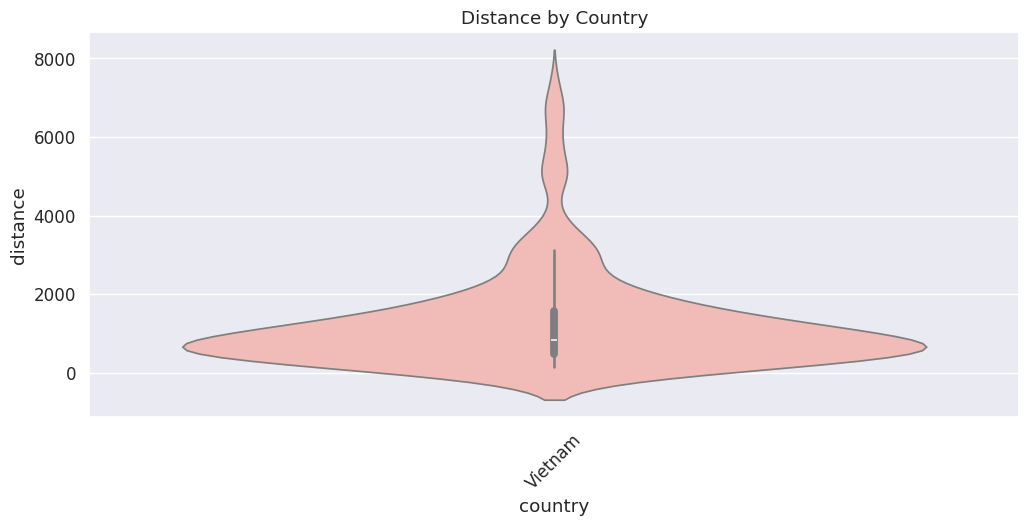

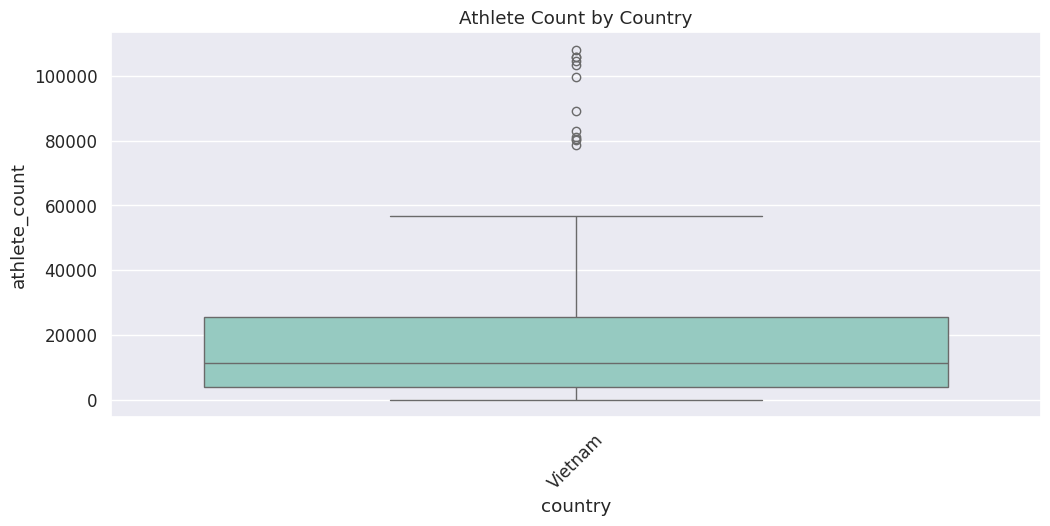

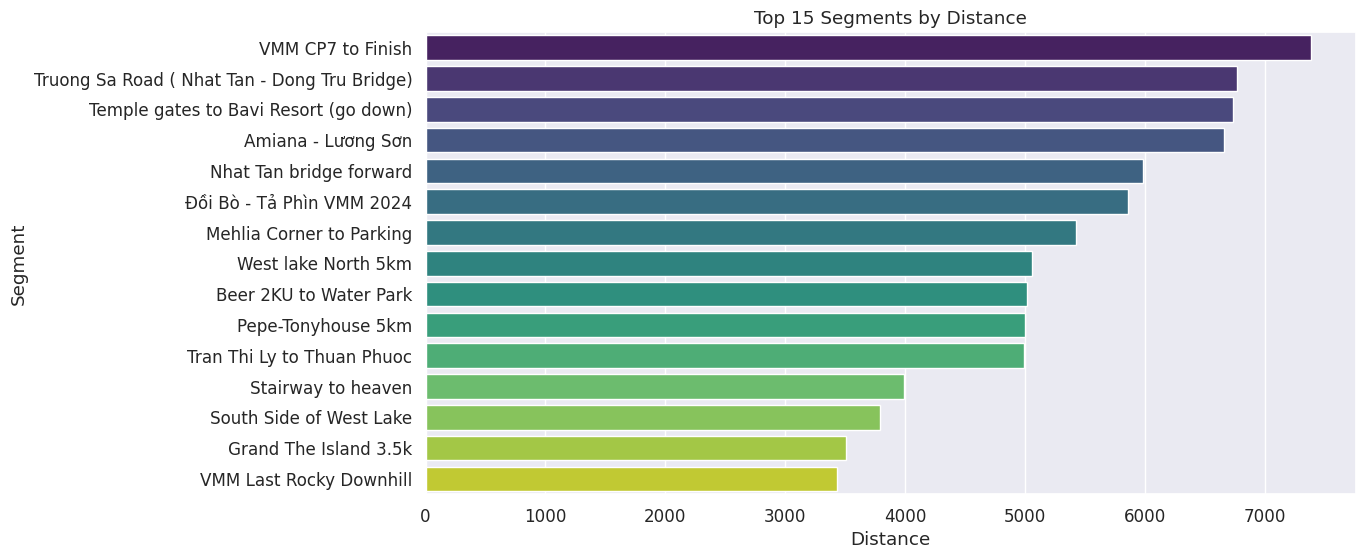

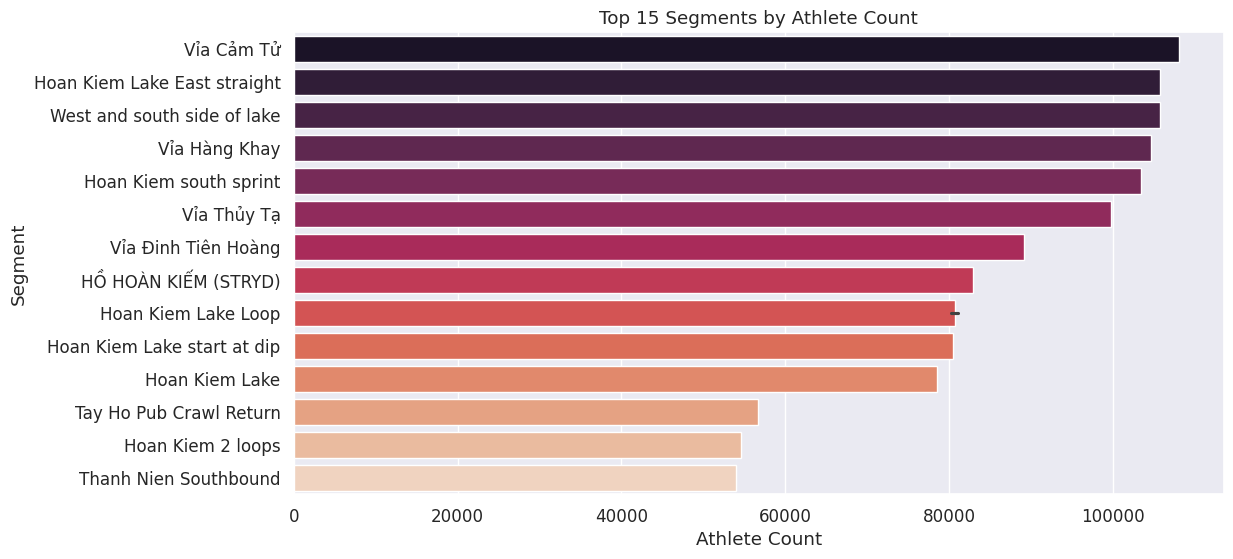

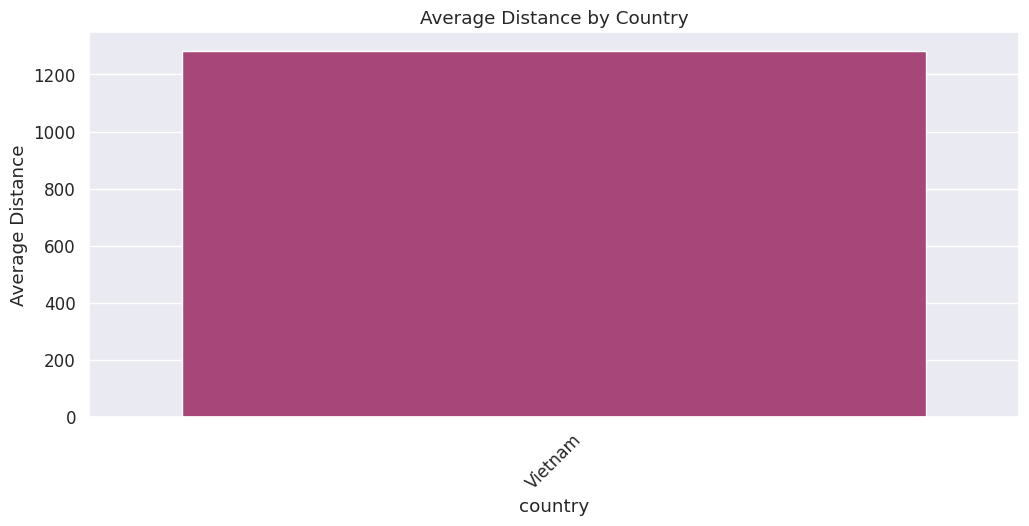

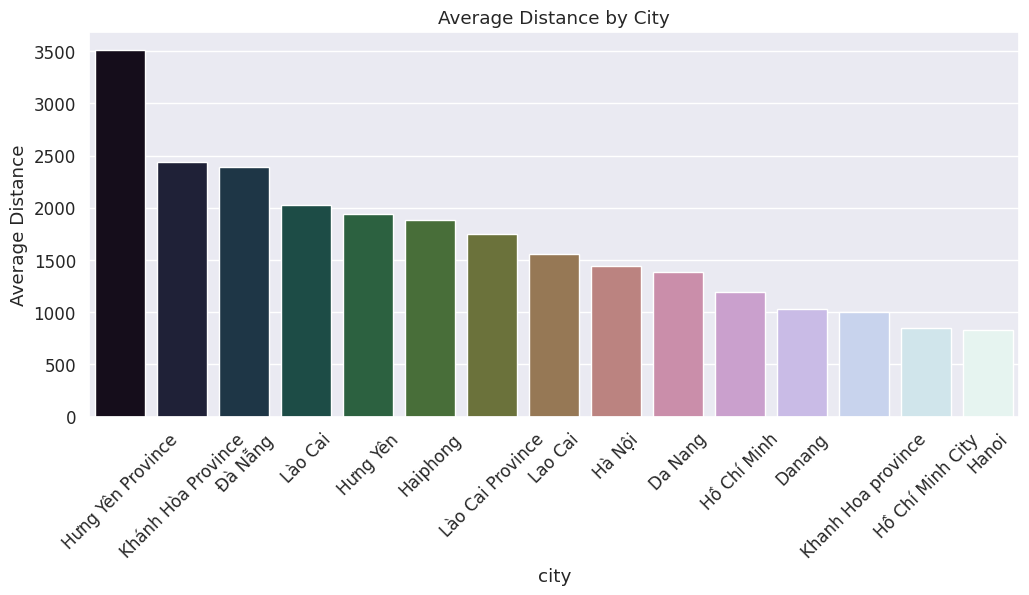

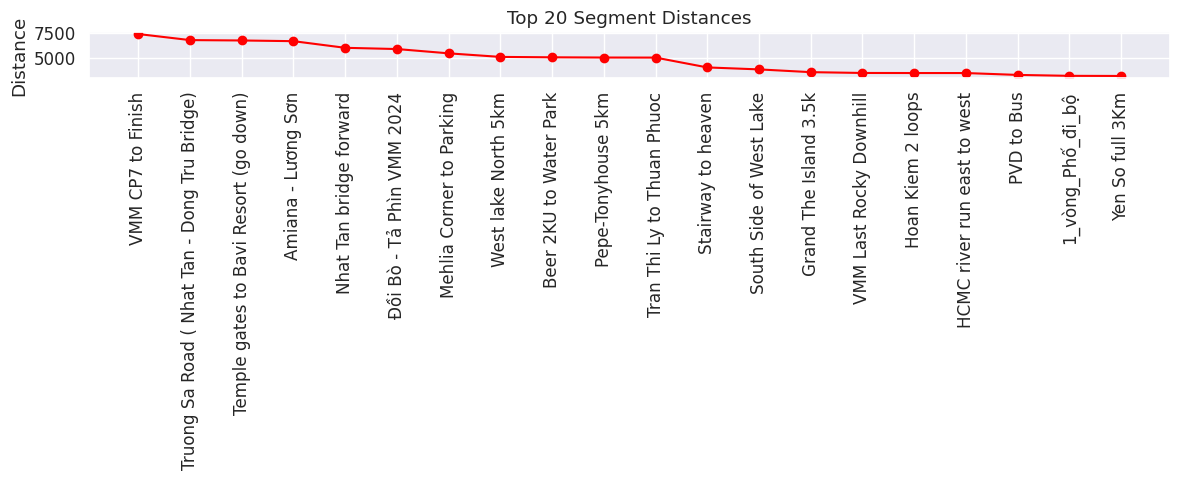

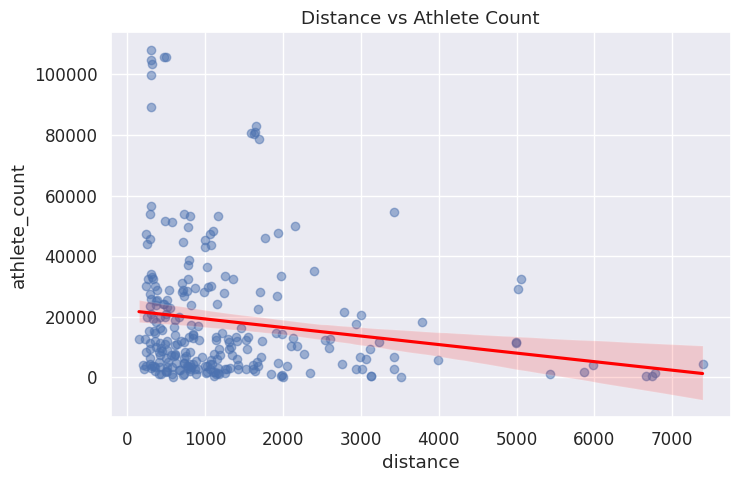

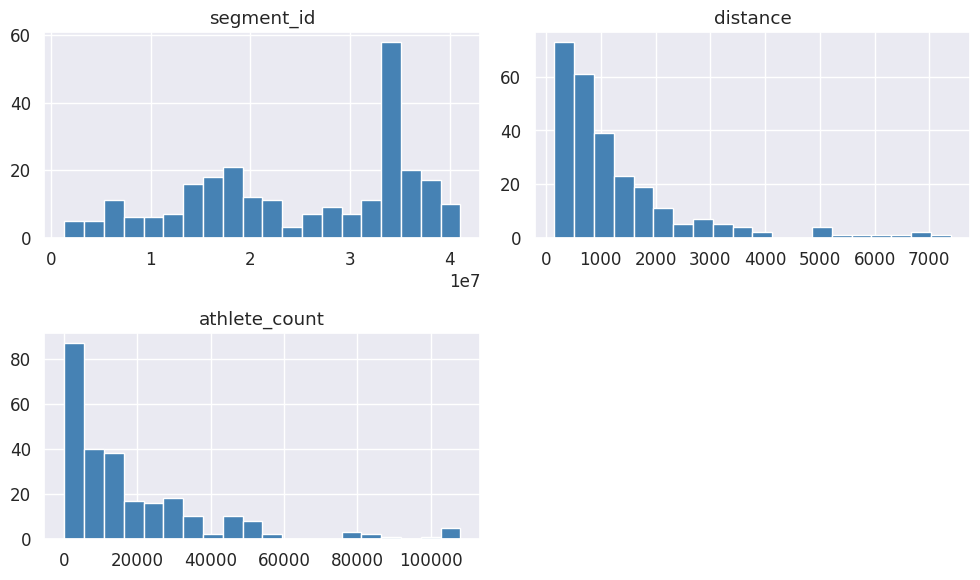

SEGMENT DATASET EDA COMPLETED SUCCESSFULLY


In [14]:
# ==========================================================
# PART 3 : ADVANCED VISUALIZATIONS
# ==========================================================

# ==========================================================
# SCATTER PLOT : DISTANCE VS ATHLETE COUNT
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="distance",
    y="athlete_count",
    hue="country",
    palette="Set2"
)

plt.title("Distance vs Athlete Count")

plt.show()

# ==========================================================
# DISTANCE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["distance"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distance Distribution")

plt.show()

# ==========================================================
# ATHLETE COUNT DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["athlete_count"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Athlete Count Distribution")

plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(6,5))

corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================================
# PAIRPLOT
# ==========================================================

pair_cols = [
    "distance",
    "athlete_count"
]

sns.pairplot(data[pair_cols])

plt.show()

# ==========================================================
# VIOLIN PLOT : COUNTRY VS DISTANCE
# ==========================================================

top_country = data["country"].value_counts().head(8).index

country_data = data[data["country"].isin(top_country)]

plt.figure(figsize=(12,5))

sns.violinplot(
    data=country_data,
    x="country",
    y="distance",
    palette="Pastel1"
)

plt.xticks(rotation=45)

plt.title("Distance by Country")

plt.show()

# ==========================================================
# BOXPLOT : COUNTRY VS ATHLETE COUNT
# ==========================================================

plt.figure(figsize=(12,5))

sns.boxplot(
    data=country_data,
    x="country",
    y="athlete_count",
    palette="Set3"
)

plt.xticks(rotation=45)

plt.title("Athlete Count by Country")

plt.show()

# ==========================================================
# TOP 15 SEGMENTS BY DISTANCE
# ==========================================================

top_distance = data.nlargest(15, "distance")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_distance,
    x="distance",
    y="name",
    palette="viridis"
)

plt.title("Top 15 Segments by Distance")

plt.xlabel("Distance")

plt.ylabel("Segment")

plt.show()

# ==========================================================
# TOP 15 SEGMENTS BY ATHLETE COUNT
# ==========================================================

top_athletes = data.nlargest(15, "athlete_count")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_athletes,
    x="athlete_count",
    y="name",
    palette="rocket"
)

plt.title("Top 15 Segments by Athlete Count")

plt.xlabel("Athlete Count")

plt.ylabel("Segment")

plt.show()

# ==========================================================
# AVERAGE DISTANCE BY COUNTRY
# ==========================================================

avg_country = (
    data.groupby("country")["distance"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=avg_country.index,
    y=avg_country.values,
    palette="magma"
)

plt.xticks(rotation=45)

plt.title("Average Distance by Country")

plt.ylabel("Average Distance")

plt.show()

# ==========================================================
# AVERAGE DISTANCE BY CITY
# ==========================================================

avg_city = (
    data.groupby("city")["distance"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=avg_city.index,
    y=avg_city.values,
    palette="cubehelix"
)

plt.xticks(rotation=45)

plt.title("Average Distance by City")

plt.ylabel("Average Distance")

plt.show()

# ==========================================================
# LINE CHART : TOP 20 SEGMENTS
# ==========================================================

top20 = data.nlargest(20, "distance")

plt.figure(figsize=(12,5))

plt.plot(
    top20["name"],
    top20["distance"],
    marker="o",
    color="red"
)

plt.xticks(rotation=90)

plt.title("Top 20 Segment Distances")

plt.ylabel("Distance")

plt.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# DISTANCE VS ATHLETE COUNT REGRESSION
# ==========================================================

plt.figure(figsize=(8,5))

sns.regplot(
    data=data,
    x="distance",
    y="athlete_count",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Distance vs Athlete Count")

plt.show()

# ==========================================================
# NUMERICAL HISTOGRAM GRID
# ==========================================================

data.select_dtypes(include=np.number).hist(
    figsize=(10,6),
    bins=20,
    color="steelblue"
)

plt.tight_layout()

plt.show()

print("="*70)
print("SEGMENT DATASET EDA COMPLETED SUCCESSFULLY")
print("="*70)

## Thanks.........Please Upvote